In [3]:
from dotenv import load_dotenv
import os
import boto3
import awswrangler as wr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

load_dotenv()

# ── Config ──────────────────────────────────────────────────────────
S3_OUTPUT = "s3://pharma-bi-raw/athena-results/"
DATABASE  = "pharma_bi_db"

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

def run_query(sql: str) -> pd.DataFrame:
    """Run an Athena SQL query and return a pandas DataFrame."""
    return wr.athena.read_sql_query(
        sql=sql,
        database=DATABASE,
        s3_output=S3_OUTPUT,
        boto3_session=session
    )

# ── Plot style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.family':       'sans-serif',
})

PROMO_COLOR     = '#E07B3A'
NON_PROMO_COLOR = '#2C6FAC'

CATEGORY_COLORS = {
    'Prescription':    '#2C6FAC',
    'OTC':             '#3A9E6F',
    'Wellness':        '#E07B3A',
    'Personal Care':   '#9B5EA0',
    'Medical Devices': '#C0392B'
}

# ── Sanity check ────────────────────────────────────────────────────
df_check = run_query("SELECT COUNT(*) AS n FROM fact_sales")
print(f"Connection OK — {df_check['n'].iloc[0]:,} rows in FactSales")

Connection OK — 62,139 rows in FactSales


In [4]:
query_overall = """
SELECT
    promoflag,
    COUNT(salesid)                                          AS transactions,
    SUM(unitssold)                                          AS total_units,
    ROUND(SUM(revenueeur), 2)                               AS total_revenue,
    ROUND(SUM(margineur), 2)                                AS total_margin,
    ROUND(AVG(CAST(unitssold AS DOUBLE)), 2)                AS avg_units,
    ROUND(AVG(revenueeur), 2)                               AS avg_revenue,
    ROUND(AVG(margineur), 2)                                AS avg_margin,
    ROUND(SUM(margineur) / SUM(revenueeur) * 100, 1)        AS margin_pct,
    ROUND(COUNT(salesid) * 100.0 / SUM(COUNT(salesid)) OVER (), 1) AS tx_share_pct,
    ROUND(SUM(revenueeur) * 100.0 / SUM(SUM(revenueeur)) OVER (), 1) AS rev_share_pct
FROM fact_sales
GROUP BY promoflag
ORDER BY promoflag
"""

df_overall = run_query(query_overall)
df_overall['label'] = df_overall['promoflag'].map({'No': 'Non-Promo', 'Yes': 'Promo'})
print(df_overall.to_string(index=False))

promoflag  transactions  total_units  total_revenue  total_margin  avg_units  avg_revenue  avg_margin  margin_pct  tx_share_pct  rev_share_pct     label
       No         54708       393608     7722676.25    2239573.20       7.19       141.16       40.94        29.0          88.0           89.4 Non-Promo
      Yes          7431        52185      911301.06     181567.87       7.02       122.64       24.43        19.9          12.0           10.6     Promo


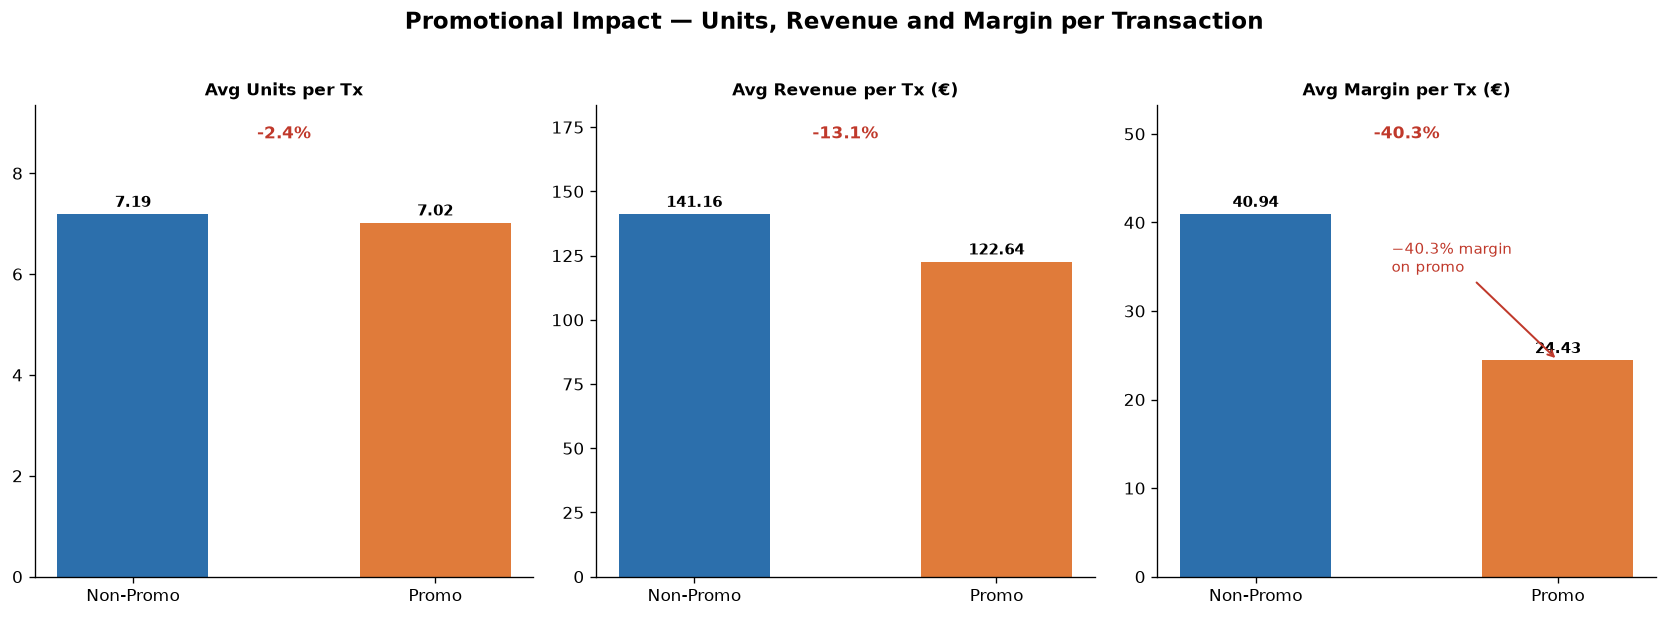

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['avg_units', 'avg_revenue', 'avg_margin']
titles  = ['Avg Units per Tx', 'Avg Revenue per Tx (€)', 'Avg Margin per Tx (€)']

non_promo = df_overall[df_overall['promoflag'] == 'No'].iloc[0]
promo     = df_overall[df_overall['promoflag'] == 'Yes'].iloc[0]

for ax, metric, title in zip(axes, metrics, titles):
    vals   = [non_promo[metric], promo[metric]]
    colors = [NON_PROMO_COLOR, PROMO_COLOR]
    bars   = ax.bar(['Non-Promo', 'Promo'], vals, color=colors, width=0.5)

    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, max(vals) * 1.3)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.02,
            f'{v:.2f}', ha='center', fontsize=9, fontweight='bold'
        )

    # Difference annotation
    diff_pct = (vals[1] - vals[0]) / vals[0] * 100
    color    = '#C0392B' if diff_pct < 0 else '#3A9E6F'
    ax.text(0.5, 0.93, f'{diff_pct:+.1f}%',
            ha='center', transform=ax.transAxes,
            fontsize=10, color=color, fontweight='bold')

# Annotate the margin drop with an arrow on the third chart
axes[2].annotate(
    f'−40.3% margin\non promo',
    xy=(1, promo['avg_margin']),
    xytext=(0.45, promo['avg_margin'] + 10),
    fontsize=9, color='#C0392B',
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2)
)

plt.suptitle('Promotional Impact — Units, Revenue and Margin per Transaction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/01_promo_overall_comparison.png', bbox_inches='tight')
plt.show()

In [6]:
query_margin_cost = """
SELECT
    SUM(CASE WHEN promoflag = 'Yes' THEN margineur ELSE 0 END)          AS actual_promo_margin,
    AVG(CASE WHEN promoflag = 'No'  THEN margineur ELSE NULL END)        AS non_promo_avg_margin,
    COUNT(CASE WHEN promoflag = 'Yes' THEN 1 END)                        AS promo_tx_count,
    COUNT(CASE WHEN promoflag = 'Yes' THEN 1 END) *
        AVG(CASE WHEN promoflag = 'No' THEN margineur ELSE NULL END)     AS counterfactual_margin,
    COUNT(CASE WHEN promoflag = 'Yes' THEN 1 END) *
        AVG(CASE WHEN promoflag = 'No' THEN margineur ELSE NULL END)
        - SUM(CASE WHEN promoflag = 'Yes' THEN margineur ELSE 0 END)     AS estimated_margin_cost,
    ROUND(
        (COUNT(CASE WHEN promoflag = 'Yes' THEN 1 END) *
         AVG(CASE WHEN promoflag = 'No' THEN margineur ELSE NULL END)
         - SUM(CASE WHEN promoflag = 'Yes' THEN margineur ELSE 0 END))
        / SUM(margineur) * 100,
    1) AS margin_cost_as_pct_of_total
FROM fact_sales
"""

df_cost = run_query(query_margin_cost)
print("── Estimated margin cost of promotions ──")
print(df_cost.T.rename(columns={0: 'value'}).to_string())

── Estimated margin cost of promotions ──
                                     value
actual_promo_margin              181567.87
non_promo_avg_margin              40.93685
promo_tx_count                        7431
counterfactual_margin        304201.733735
estimated_margin_cost        122633.863735
margin_cost_as_pct_of_total            5.1


In [7]:
query_cat = """
SELECT
    dpr.category,
    fs.promoflag,
    COUNT(fs.salesid)                                       AS transactions,
    ROUND(AVG(CAST(fs.unitssold AS DOUBLE)), 2)             AS avg_units,
    ROUND(AVG(fs.revenueeur), 2)                            AS avg_revenue,
    ROUND(AVG(fs.margineur), 2)                             AS avg_margin,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.category, fs.promoflag
ORDER BY dpr.category, fs.promoflag
"""

df_cat = run_query(query_cat)
print(df_cat.to_string(index=False))
categories = ['Prescription', 'OTC', 'Wellness', 'Personal Care', 'Medical Devices']

       category promoflag  transactions  avg_units  avg_revenue  avg_margin  margin_pct
Medical Devices        No          5321       2.30       146.52       37.97        25.9
Medical Devices       Yes           730       2.26       127.33       21.63        17.0
            OTC        No         17096       9.17        94.21       28.54        30.3
            OTC       Yes          2316       9.03        80.64       17.39        21.6
  Personal Care        No          9785       9.22       134.29       46.03        34.3
  Personal Care       Yes          1288       8.77       109.13       28.28        25.9
   Prescription        No         11514       4.82       215.76       49.52        22.9
   Prescription       Yes          1606       4.84       194.74       26.81        13.8
       Wellness        No         10992       7.18       139.57       48.13        34.5
       Wellness       Yes          1491       7.07       119.56       30.87        25.8


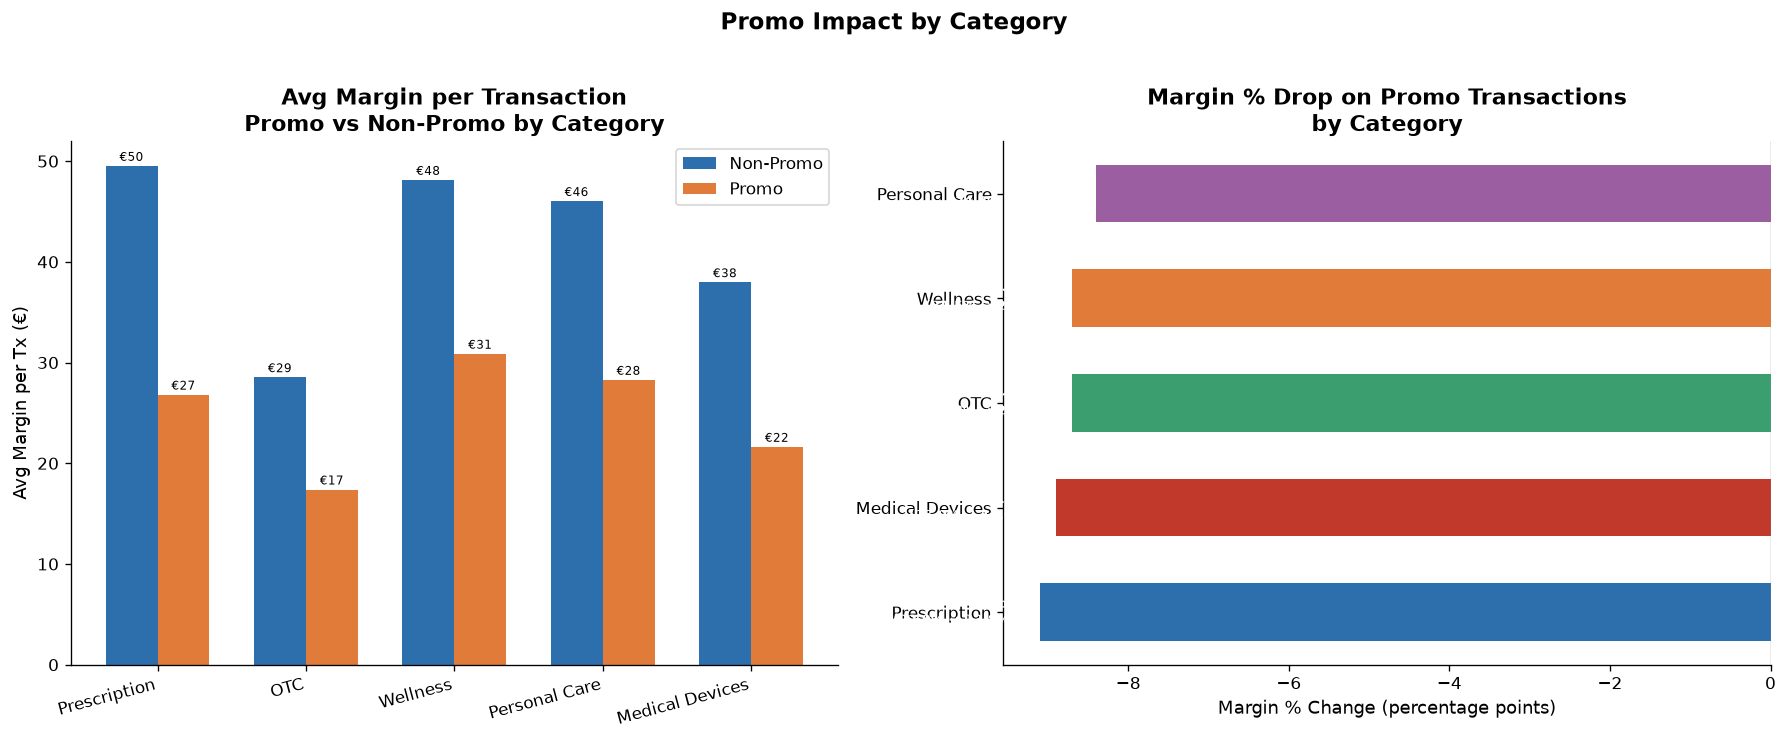

In [8]:

fig, axes  = plt.subplots(1, 2, figsize=(15, 6))

# ── Chart 1: Avg margin per tx by category — promo vs non-promo ──────
x = np.arange(len(categories))
w = 0.35

for i, (flag, label, color) in enumerate(zip(
        ['No', 'Yes'], ['Non-Promo', 'Promo'], [NON_PROMO_COLOR, PROMO_COLOR])):
    vals = [
        df_cat[(df_cat['category'] == cat) &
               (df_cat['promoflag'] == flag)]['avg_margin'].values
        for cat in categories
    ]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    offset = (i - 0.5) * w
    bars = axes[0].bar(x + offset, vals, width=w, label=label, color=color)

    for bar, v in zip(bars, vals):
        if v > 0:
            axes[0].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'€{v:.0f}', ha='center', fontsize=7
            )

axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=15, ha='right')
axes[0].set_ylabel('Avg Margin per Tx (€)')
axes[0].set_title('Avg Margin per Transaction\nPromo vs Non-Promo by Category', fontweight='bold')
axes[0].legend()

# ── Chart 2: Margin % drop — promo vs non-promo by category ──────────
margin_drop = []
for cat in categories:
    np_val = df_cat[(df_cat['category'] == cat) &
                    (df_cat['promoflag'] == 'No')]['margin_pct'].values
    p_val  = df_cat[(df_cat['category'] == cat) &
                    (df_cat['promoflag'] == 'Yes')]['margin_pct'].values
    if len(np_val) > 0 and len(p_val) > 0:
        margin_drop.append({
            'category':       cat,
            'non_promo_pct':  np_val[0],
            'promo_pct':      p_val[0],
            'drop_pp':        round(p_val[0] - np_val[0], 1)
        })

df_drop = pd.DataFrame(margin_drop).sort_values('drop_pp')
bar_colors = [CATEGORY_COLORS[c] for c in df_drop['category']]

bars = axes[1].barh(df_drop['category'], df_drop['drop_pp'], color=bar_colors, height=0.55)
axes[1].set_xlabel('Margin % Change (percentage points)')
axes[1].set_title('Margin % Drop on Promo Transactions\nby Category', fontweight='bold')
axes[1].axvline(x=0, color='#888', linewidth=0.8)

for bar, row in zip(bars, df_drop.itertuples()):
    axes[1].text(
        bar.get_width() - 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{row.drop_pp:.1f}pp\n({row.non_promo_pct}% → {row.promo_pct}%)',
        va='center', ha='right', fontsize=8, color='white', fontweight='bold'
    )

plt.suptitle('Promo Impact by Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/02_promo_impact_by_category.png', bbox_inches='tight')
plt.show()

In [9]:
query_promo_rate = """
SELECT
    dpr.category,
    COUNT(fs.salesid)                                               AS total_transactions,
    COUNT(CASE WHEN fs.promoflag = 'Yes' THEN 1 END)               AS promo_transactions,
    ROUND(
        COUNT(CASE WHEN fs.promoflag = 'Yes' THEN 1 END) * 100.0
        / COUNT(fs.salesid),
    1) AS promo_rate_pct
FROM fact_sales fs
JOIN dim_product dpr ON fs.productid = dpr.productid
GROUP BY dpr.category
ORDER BY promo_rate_pct DESC
"""

df_rate = run_query(query_promo_rate)
print(df_rate.to_string(index=False))

       category  total_transactions  promo_transactions  promo_rate_pct
   Prescription               13120                1606            12.2
Medical Devices                6051                 730            12.1
            OTC               19412                2316            11.9
       Wellness               12483                1491            11.9
  Personal Care               11073                1288            11.6


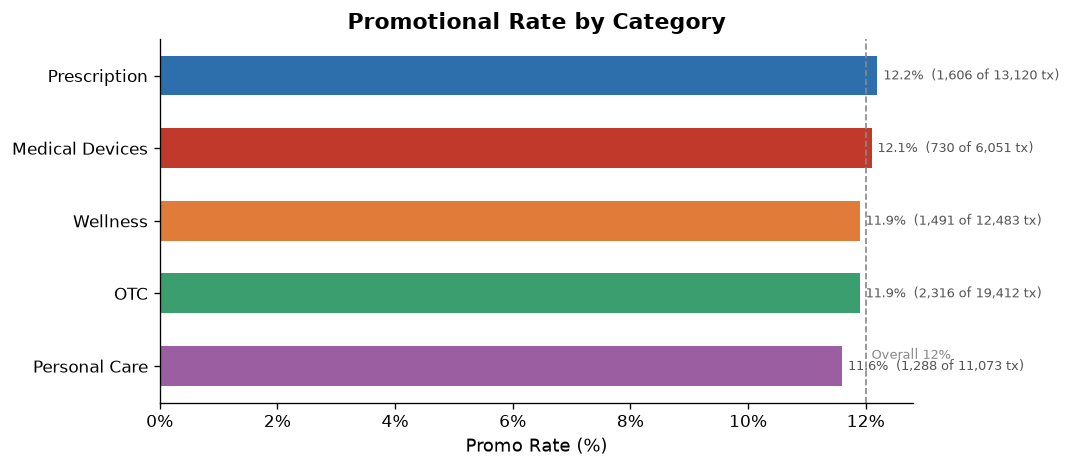

In [10]:

fig, ax = plt.subplots(figsize=(9, 4))

bar_colors = [CATEGORY_COLORS[c] for c in df_rate.sort_values('promo_rate_pct')['category']]

bars = ax.barh(
    df_rate.sort_values('promo_rate_pct')['category'],
    df_rate.sort_values('promo_rate_pct')['promo_rate_pct'],
    color=bar_colors, height=0.55
)
ax.set_xlabel('Promo Rate (%)')
ax.set_title('Promotional Rate by Category', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.axvline(x=12.0, color='#888', linewidth=1, linestyle='--')
ax.text(12.1, 0.1, 'Overall 12%', fontsize=8, color='#888')

for bar, row in zip(bars, df_rate.sort_values('promo_rate_pct').itertuples()):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{row.promo_rate_pct}%  ({row.promo_transactions:,} of {row.total_transactions:,} tx)',
        va='center', fontsize=8, color='#555'
    )

plt.tight_layout()
plt.savefig('outputs/03_promo_rate_by_category.png', bbox_inches='tight')
plt.show()

In [11]:
query_country = """
SELECT
    dp.country,
    fs.promoflag,
    COUNT(fs.salesid)                                       AS transactions,
    ROUND(AVG(fs.revenueeur), 2)                            AS avg_revenue,
    ROUND(AVG(fs.margineur), 2)                             AS avg_margin,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.country, fs.promoflag
ORDER BY dp.country, fs.promoflag
"""

df_country = run_query(query_country)
print(df_country.to_string(index=False))

    country promoflag  transactions  avg_revenue  avg_margin  margin_pct
    Austria        No          4150       147.84       42.89        29.0
    Austria       Yes           543       128.41       26.60        20.7
    Belgium        No          7320       152.88       44.52        29.1
    Belgium       Yes           960       132.70       26.16        19.7
     France        No          8986       140.01       40.51        28.9
     France       Yes          1201       123.77       24.73        20.0
    Germany        No          9355       149.66       43.39        29.0
    Germany       Yes          1273       131.65       26.17        19.9
      Italy        No          8707       137.04       39.79        29.0
      Italy       Yes          1165       119.31       23.96        20.1
Netherlands        No          5403       157.59       45.53        28.9
Netherlands       Yes           735       131.01       26.09        19.9
     Poland        No          5833       109.35   

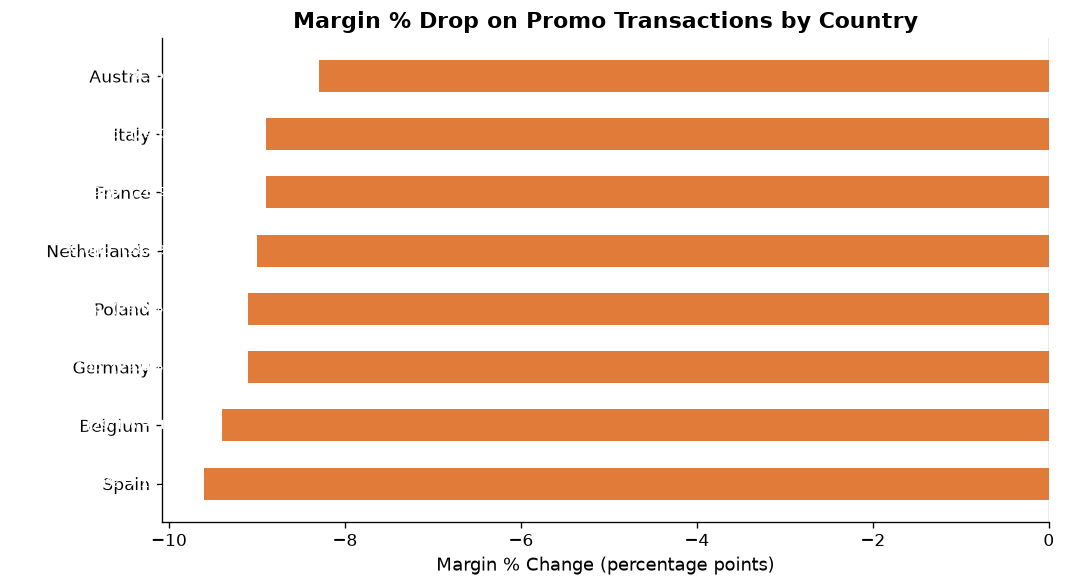

In [12]:

# Margin % drop by country
countries = df_country['country'].unique()
country_drop = []

for country in countries:
    np_val = df_country[(df_country['country'] == country) &
                        (df_country['promoflag'] == 'No')]['margin_pct'].values
    p_val  = df_country[(df_country['country'] == country) &
                        (df_country['promoflag'] == 'Yes')]['margin_pct'].values
    if len(np_val) > 0 and len(p_val) > 0:
        country_drop.append({
            'country':       country,
            'non_promo_pct': np_val[0],
            'promo_pct':     p_val[0],
            'drop_pp':       round(p_val[0] - np_val[0], 1)
        })

df_cdrop = pd.DataFrame(country_drop).sort_values('drop_pp')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    df_cdrop['country'],
    df_cdrop['drop_pp'],
    color='#E07B3A', height=0.55
)
ax.set_xlabel('Margin % Change (percentage points)')
ax.set_title('Margin % Drop on Promo Transactions by Country', fontweight='bold')
ax.axvline(x=0, color='#888', linewidth=0.8)

for bar, row in zip(bars, df_cdrop.itertuples()):
    ax.text(
        bar.get_width() - 0.15,
        bar.get_y() + bar.get_height() / 2,
        f'{row.drop_pp:.1f}pp  ({row.non_promo_pct}% → {row.promo_pct}%)',
        va='center', ha='right', fontsize=8, color='white', fontweight='bold'
    )

plt.tight_layout()
plt.savefig('outputs/04_promo_margin_drop_by_country.png', bbox_inches='tight')
plt.show()

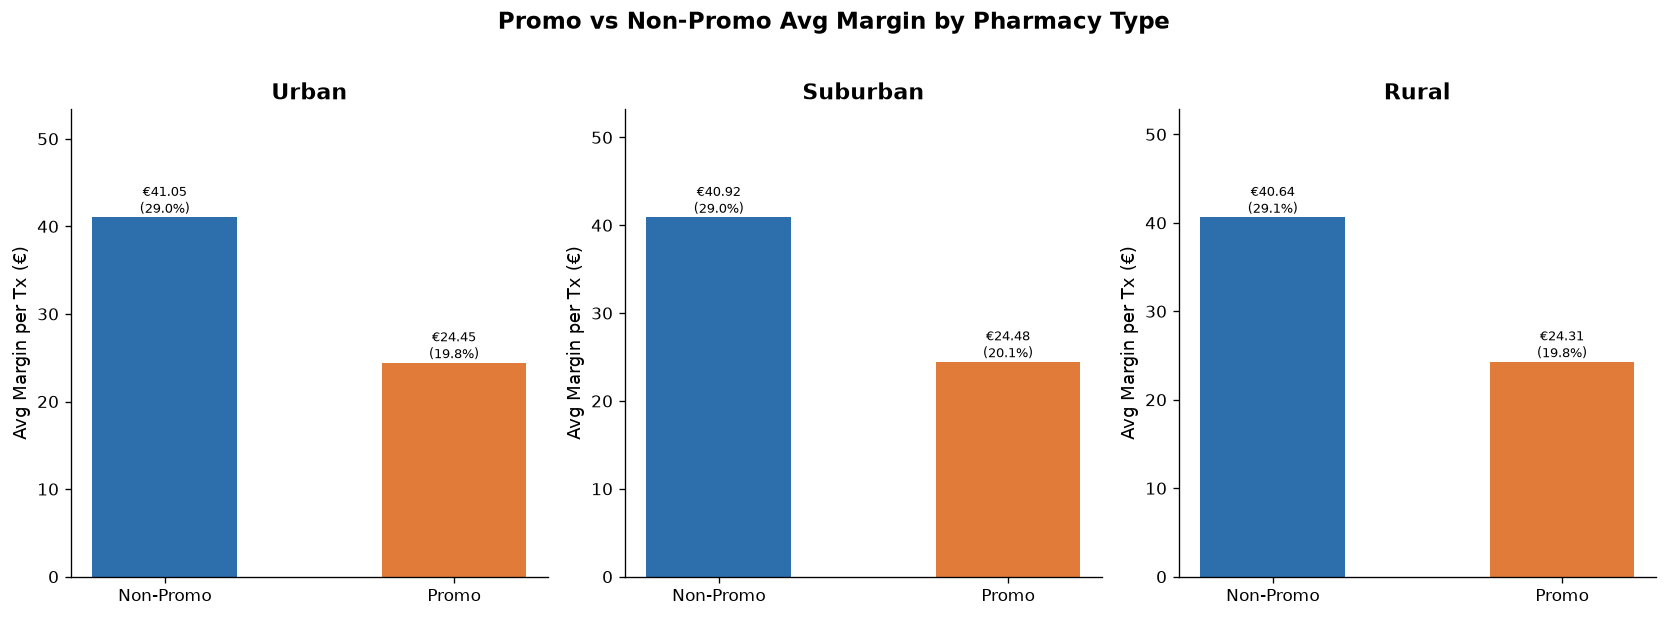

In [13]:
query_phtype = """
SELECT
    dp.pharmacytype,
    fs.promoflag,
    COUNT(fs.salesid)                                       AS transactions,
    ROUND(AVG(fs.revenueeur), 2)                            AS avg_revenue,
    ROUND(AVG(fs.margineur), 2)                             AS avg_margin,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.pharmacytype, fs.promoflag
ORDER BY dp.pharmacytype, fs.promoflag
"""

df_phtype = run_query(query_phtype)

pharmacy_types = ['Urban', 'Suburban', 'Rural']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, phtype in zip(axes, pharmacy_types):
    subset = df_phtype[df_phtype['pharmacytype'] == phtype]
    labels = subset['promoflag'].map({'No': 'Non-Promo', 'Yes': 'Promo'}).tolist()
    vals   = subset['avg_margin'].tolist()
    colors = [NON_PROMO_COLOR, PROMO_COLOR]

    bars = ax.bar(labels, vals, color=colors, width=0.5)
    ax.set_title(f'{phtype}', fontweight='bold')
    ax.set_ylabel('Avg Margin per Tx (€)')
    ax.set_ylim(0, max(vals) * 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, row in zip(bars, subset.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'€{row.avg_margin:.2f}\n({row.margin_pct}%)',
            ha='center', fontsize=8
        )

plt.suptitle('Promo vs Non-Promo Avg Margin by Pharmacy Type',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/05_promo_by_pharmacy_type.png', bbox_inches='tight')
plt.show()

In [14]:
query_monthly = """
SELECT
    dd.year,
    dd.monthnumber,
    dd.monthname,
    COUNT(CASE WHEN fs.promoflag = 'Yes' THEN 1 END)   AS promo_transactions,
    COUNT(fs.salesid)                                   AS total_transactions,
    ROUND(
        COUNT(CASE WHEN fs.promoflag = 'Yes' THEN 1 END) * 100.0
        / COUNT(fs.salesid),
    1) AS monthly_promo_rate_pct
FROM fact_sales fs
JOIN dim_date dd ON fs.datekey = dd.datekey
GROUP BY dd.year, dd.monthnumber, dd.monthname
ORDER BY dd.year, dd.monthnumber
"""

df_monthly = run_query(query_monthly)
df_2024 = df_monthly[df_monthly['year'] == 2024].reset_index(drop=True)
df_2025 = df_monthly[df_monthly['year'] == 2025].reset_index(drop=True)
months  = df_2024['monthname'].str[:3].tolist()

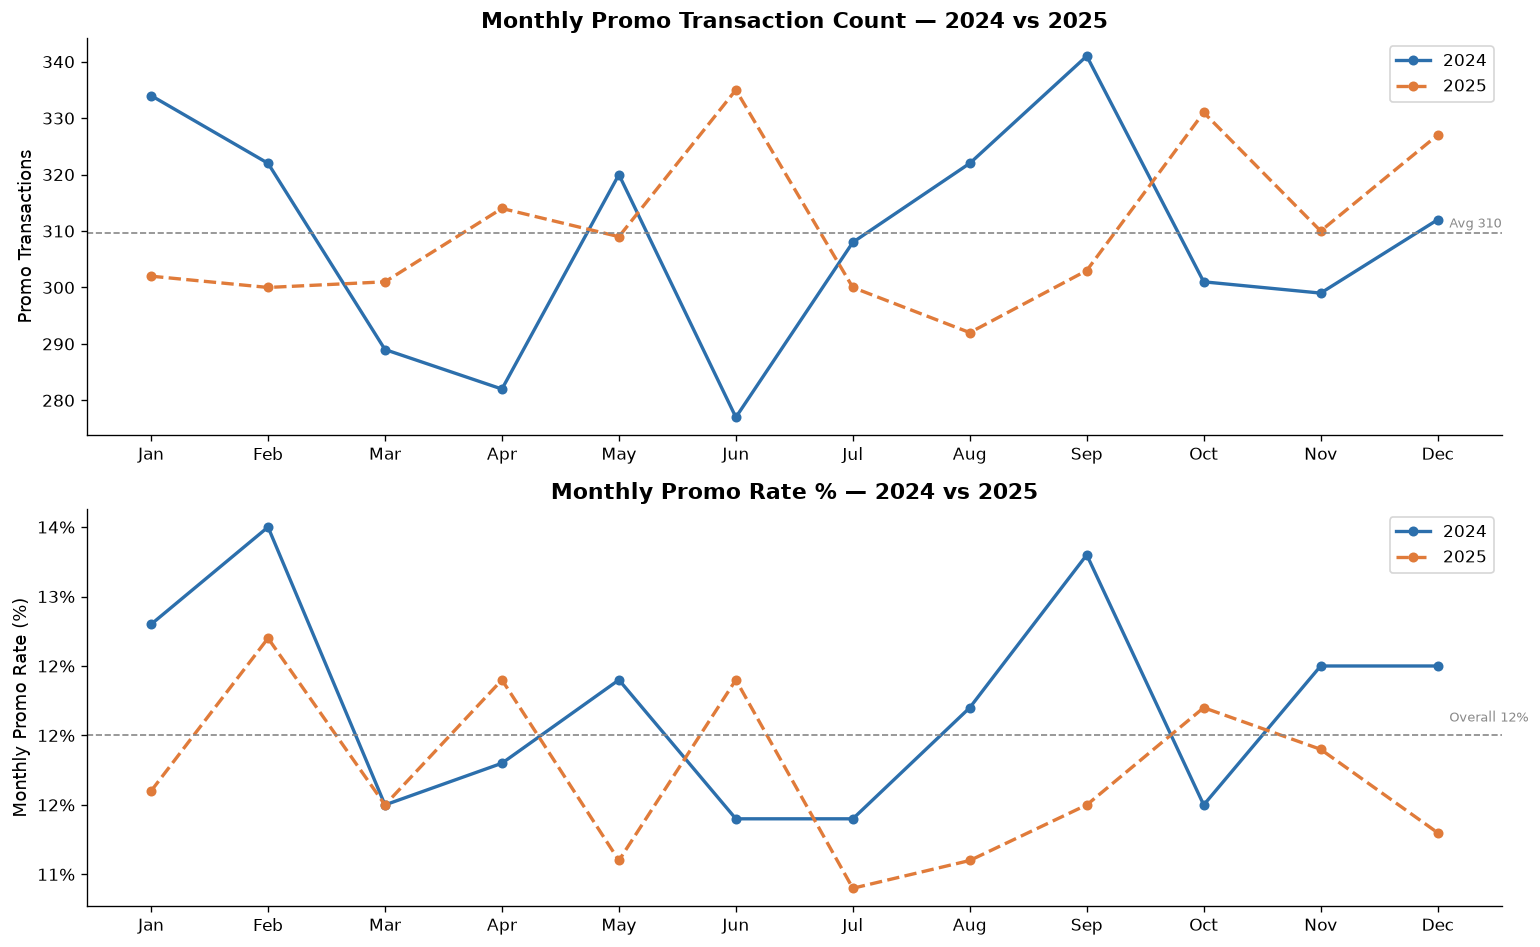

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

x = range(len(months))

# ── Chart 1: Monthly promo transaction count ─────────────────────────
axes[0].plot(x, df_2024['promo_transactions'], marker='o', linewidth=2,
             color=NON_PROMO_COLOR, label='2024', markersize=5)
axes[0].plot(x, df_2025['promo_transactions'], marker='o', linewidth=2,
             color=PROMO_COLOR, label='2025', markersize=5, linestyle='--')
axes[0].set_xticks(x)
axes[0].set_xticklabels(months)
axes[0].set_ylabel('Promo Transactions')
axes[0].set_title('Monthly Promo Transaction Count — 2024 vs 2025', fontweight='bold')
axes[0].legend()

# Reference line — overall monthly average
avg_promo = df_monthly['promo_transactions'].mean()
axes[0].axhline(y=avg_promo, color='#888', linewidth=1, linestyle='--')
axes[0].text(11.1, avg_promo + 1, f'Avg {avg_promo:.0f}', fontsize=8, color='#888')

# ── Chart 2: Monthly promo rate % ───────────────────────────────────
axes[1].plot(x, df_2024['monthly_promo_rate_pct'], marker='o', linewidth=2,
             color=NON_PROMO_COLOR, label='2024', markersize=5)
axes[1].plot(x, df_2025['monthly_promo_rate_pct'], marker='o', linewidth=2,
             color=PROMO_COLOR, label='2025', markersize=5, linestyle='--')
axes[1].set_xticks(x)
axes[1].set_xticklabels(months)
axes[1].set_ylabel('Monthly Promo Rate (%)')
axes[1].set_title('Monthly Promo Rate % — 2024 vs 2025', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].legend()
axes[1].axhline(y=12.0, color='#888', linewidth=1, linestyle='--')
axes[1].text(11.1, 12.1, 'Overall 12%', fontsize=8, color='#888')

plt.tight_layout()
plt.savefig('outputs/06_monthly_promo_trend.png', bbox_inches='tight')
plt.show()

In [16]:
# Overall promo comparison
df_overall.to_csv('../../data/processed/promo_overall.csv', index=False)

# By category
df_cat.to_csv('../../data/processed/promo_by_category.csv', index=False)

# Promo rate by category
df_rate.to_csv('../../data/processed/promo_rate_by_category.csv', index=False)

# By country
df_country.to_csv('../../data/processed/promo_by_country.csv', index=False)

# By pharmacy type
df_phtype.to_csv('../../data/processed/promo_by_pharmacy_type.csv', index=False)

# Monthly trend
df_monthly.to_csv('../../data/processed/promo_monthly_trend.csv', index=False)

# Margin cost
df_cost.to_csv('../../data/processed/promo_margin_cost.csv', index=False)

print("All CSVs exported to data/processed/")
print()
print("Files created:")
print("  promo_overall.csv")
print("  promo_by_category.csv")
print("  promo_rate_by_category.csv")
print("  promo_by_country.csv")
print("  promo_by_pharmacy_type.csv")
print("  promo_monthly_trend.csv")
print("  promo_margin_cost.csv")

All CSVs exported to data/processed/

Files created:
  promo_overall.csv
  promo_by_category.csv
  promo_rate_by_category.csv
  promo_by_country.csv
  promo_by_pharmacy_type.csv
  promo_monthly_trend.csv
  promo_margin_cost.csv


In [17]:
summary = """
MODULE 3 — PROMOTIONAL IMPACT ANALYSIS
=======================================

OVERALL FINDINGS
----------------
- 7,431 promo transactions (12% of all transactions)
- Promo revenue: €911,301 (10.6% of total revenue)
- Avg units per tx:    7.02 promo vs 7.19 non-promo  (−2.4% — no uplift)
- Avg revenue per tx:  €122.64 vs €141.16            (−13.1%)
- Avg margin per tx:   €24.43  vs €40.94             (−40.3%)
- Margin %:            19.9%   vs 29.0%              (−9.1pp)

MARGIN COST CALCULATION
-----------------------
- Actual margin from 7,431 promo transactions: €181,568
- Counterfactual margin (at non-promo avg):    €304,202
- Estimated margin cost of promotions:         €122,634
- This represents 5.1% of total margin given away with no evidence
  of volume or revenue return

CATEGORY FINDINGS
-----------------
- Prescription: largest margin drop (22.9% → 13.8%, −9.1pp)
  — already the lowest-margin category, further compressed by promos
- Wellness: 34.5% → 25.8% (−8.7pp) — highest absolute margin, biggest loss
- Promo margin erosion is consistent across all 5 categories
- Promo rate is uniform across categories (11.6%–12.2%)
  — no category is being protected from promotional discounting

GEOGRAPHIC FINDINGS
-------------------
- Margin drop consistent across all 8 countries (~29% → ~20%)
- Promotional impact is structural, not country-specific

PHARMACY TYPE FINDINGS
----------------------
- Impact identical across Urban, Suburban, and Rural
- No pharmacy type is shielded from margin erosion on promo

SEASONALITY OF PROMOTIONS
--------------------------
- Promo transactions are evenly distributed across all 12 months
- No tactical use of promotions to lift slow months
- Promotions appear to be applied uniformly rather than strategically

CENTRAL CONCLUSION
------------------
Promotions are margin-destructive with no compensating volume uplift.
They cost an estimated €122,634 in margin (5.1% of total) over 2 years.
A targeted promotional strategy — protecting high-margin categories
(Wellness, Personal Care) and focusing promos on slow months —
could recover a meaningful portion of this margin.

CHARTS SAVED
------------
  outputs/01_promo_overall_comparison.png
  outputs/02_promo_impact_by_category.png
  outputs/03_promo_rate_by_category.png
  outputs/04_promo_margin_drop_by_country.png
  outputs/05_promo_by_pharmacy_type.png
  outputs/06_monthly_promo_trend.png

CSVs EXPORTED
-------------
  data/processed/promo_overall.csv
  data/processed/promo_by_category.csv
  data/processed/promo_rate_by_category.csv
  data/processed/promo_by_country.csv
  data/processed/promo_by_pharmacy_type.csv
  data/processed/promo_monthly_trend.csv
  data/processed/promo_margin_cost.csv
"""

print(summary)


MODULE 3 — PROMOTIONAL IMPACT ANALYSIS

OVERALL FINDINGS
----------------
- 7,431 promo transactions (12% of all transactions)
- Promo revenue: €911,301 (10.6% of total revenue)
- Avg units per tx:    7.02 promo vs 7.19 non-promo  (−2.4% — no uplift)
- Avg revenue per tx:  €122.64 vs €141.16            (−13.1%)
- Avg margin per tx:   €24.43  vs €40.94             (−40.3%)
- Margin %:            19.9%   vs 29.0%              (−9.1pp)

MARGIN COST CALCULATION
-----------------------
- Actual margin from 7,431 promo transactions: €181,568
- Counterfactual margin (at non-promo avg):    €304,202
- Estimated margin cost of promotions:         €122,634
- This represents 5.1% of total margin given away with no evidence
  of volume or revenue return

CATEGORY FINDINGS
-----------------
- Prescription: largest margin drop (22.9% → 13.8%, −9.1pp)
  — already the lowest-margin category, further compressed by promos
- Wellness: 34.5% → 25.8% (−8.7pp) — highest absolute margin, biggest loss
- Promo